<a href="https://colab.research.google.com/github/muhammad-bin-nasir/Sentiment-Analysis/blob/main/SentimentAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define your project directory paths
# IMPORTANT: Change 'Your_Project_Folder' to your actual folder name
base_path = '/content/drive/My Drive/Sentiment analysis'
audio_folder = os.path.join(base_path, 'Audio')
labels_csv = os.path.join(base_path, 'labels_fixed.csv')

# Create Output/MFCC directory if it doesn't exist
output_dir = os.path.join(base_path, 'Output', 'MFCC')
os.makedirs(output_dir, exist_ok=True)

print(f"✅ Output will be saved to: {output_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Output will be saved to: /content/drive/My Drive/Sentiment analysis/Output/MFCC


<h1> MFCC

.npy files for traininng

In [14]:
import os
import numpy as np
import pandas as pd
import librosa
from tqdm.auto import tqdm

def extract_rich_features(audio_path):
    """
    Extracts a combined vector of MFCC, Chroma, and Spectral Contrast.
    """
    try:
        y, sr = librosa.load(audio_path, sr=None)

        # 1. MFCC (40 coefficients) - captures vocal tract shape
        mfccs = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)

        # 2. Chroma (12 coefficients) - captures harmonic/pitch energy
        chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr).T, axis=0)

        # 3. Spectral Contrast (7 coefficients) - captures dynamic range/texture
        contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr).T, axis=0)

        return np.hstack([mfccs, chroma, contrast])
    except Exception as e:
        return None

def make_rich_features(audio_folder, labels_csv, output_path):
    df = pd.read_csv(labels_csv)
    features, labels = [], []

    x_file = os.path.join(output_path, "features_RICH.npy")
    y_file = os.path.join(output_path, "labels_RICH.npy")

    for _, row in tqdm(df.iterrows(), total=df.shape[0], desc="Extracting Rich Features"):
        audio_path = os.path.join(audio_folder, row["filename"])
        if os.path.exists(audio_path):
            feat = extract_rich_features(audio_path)
            if feat is not None:
                features.append(feat)
                labels.append(row["label"])

    X, y = np.array(features), np.array(labels)
    np.save(x_file, X)
    np.save(y_file, y)
    print(f"\n✅ Saved {X.shape[0]} samples with {X.shape[1]} features each.")

# Execute (using paths defined in previous steps)
make_rich_features(audio_folder, labels_csv, output_dir)

Extracting Rich Features:   0%|          | 0/12438 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(



✅ Saved 12438 samples with 59 features each.


Verification

In [9]:
import numpy as np
import os

# Define the paths to your saved files
x_file = os.path.join(output_dir, "features_MFCC.npy")
y_file = os.path.join(output_dir, "labels_MFCC.npy")

# Load the data
X_loaded = np.load(x_file)
y_loaded = np.load(y_file)

# Check shapes
print(f"📊 Feature matrix shape: {X_loaded.shape}") # Expected: (samples, 173)
print(f"📊 Labels array shape: {y_loaded.shape}")    # Expected: (samples,)
print(f"✅ Data verified and ready for training.")

📊 Feature matrix shape: (12438, 173)
📊 Labels array shape: (12438,)
✅ Data verified and ready for training.


MLP training

In [15]:
# Load the new rich features
X_loaded = np.load(os.path.join(output_dir, "features_RICH.npy"))
y_loaded = np.load(os.path.join(output_dir, "labels_RICH.npy"))

# Preprocessing
le = LabelEncoder()
y_encoded = le.fit_transform(y_loaded)
num_classes = len(le.classes_)

# Split & Scale
indices = np.arange(len(X_loaded))
np.random.shuffle(indices)
train_idx, val_idx = indices[:int(0.8*len(indices))], indices[int(0.8*len(indices)):]

scaler = StandardScaler()
X_train = torch.tensor(scaler.fit_transform(X_loaded[train_idx]), dtype=torch.float32)
X_val = torch.tensor(scaler.transform(X_loaded[val_idx]), dtype=torch.float32)
y_train = torch.tensor(y_encoded[train_idx], dtype=torch.long)
y_val = torch.tensor(y_encoded[val_idx], dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32)

# Model - Note the input_size=59
model = SentimentMLP_Deep(input_size=59, num_classes=num_classes).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
criterion = nn.CrossEntropyLoss()

# Training Loop
epochs = 100
pbar = tqdm(range(epochs), desc="Training with Rich Features")

for epoch in pbar:
    model.train()
    t_loss = 0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        loss = criterion(model(bx), by)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for vx, vy in val_loader:
            vx, vy = vx.to(device), vy.to(device)
            outputs = model(vx)
            correct += (outputs.argmax(1) == vy).sum().item()
            total += vy.size(0)

    val_acc = 100 * correct / total
    scheduler.step(val_acc)
    pbar.set_postfix({'Acc': f'{val_acc:.2f}%', 'LR': f"{optimizer.param_groups[0]['lr']:.6f}"})

print(f"\n🎉 Training complete. Final Accuracy: {val_acc:.2f}%")

Training with Rich Features:   0%|          | 0/100 [00:00<?, ?it/s]


🎉 Training complete. Final Accuracy: 65.76%


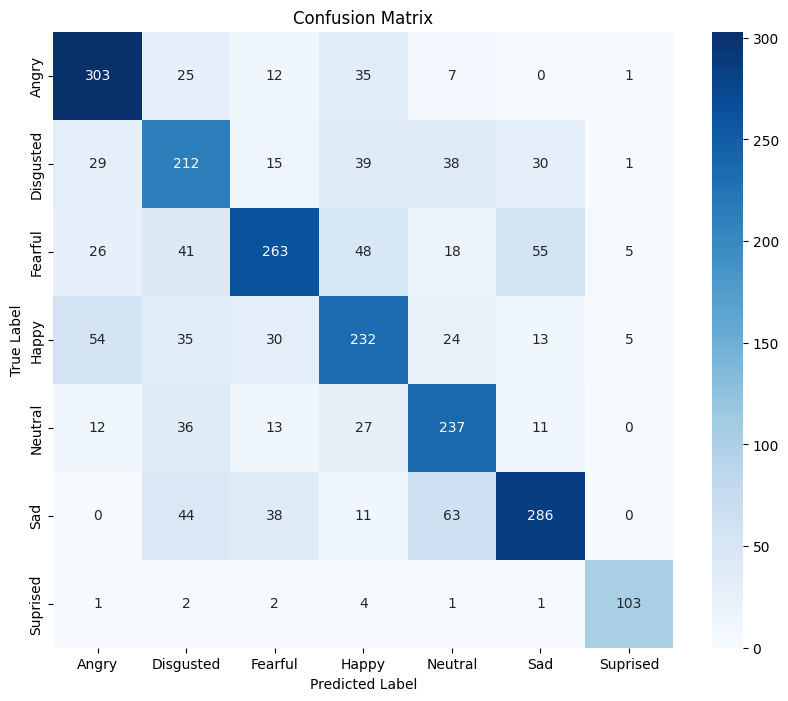


📊 --- Class-wise Accuracy ---
✨ Angry          : 79.11%
✨ Disgusted      : 58.24%
✨ Fearful        : 57.68%
✨ Happy          : 59.03%
✨ Neutral        : 70.54%
✨ Sad            : 64.71%
✨ Suprised       : 90.35%

📝 --- Detailed Classification Report ---
              precision    recall  f1-score   support

       Angry       0.71      0.79      0.75       383
   Disgusted       0.54      0.58      0.56       364
     Fearful       0.71      0.58      0.63       456
       Happy       0.59      0.59      0.59       393
     Neutral       0.61      0.71      0.65       336
         Sad       0.72      0.65      0.68       442
    Suprised       0.90      0.90      0.90       114

    accuracy                           0.66      2488
   macro avg       0.68      0.69      0.68      2488
weighted avg       0.66      0.66      0.66      2488



In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def plot_metrics(model, loader, device, le):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 1. Get Class Names
    class_names = le.classes_

    # 2. Generate Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    # 3. Calculate Class-wise Accuracy
    cm_acc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    class_wise_acc = cm_acc.diagonal() * 100

    # 4. Visualization
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    # 5. Print Detailed Stats
    print("\n📊 --- Class-wise Accuracy ---")
    for i, class_name in enumerate(class_names):
        print(f"✨ {class_name:15}: {class_wise_acc[i]:.2f}%")

    print("\n📝 --- Detailed Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=class_names))

# Execute the metrics function
plot_metrics(model, val_loader, device, le)

<h1>Bovw

npy extraction

In [18]:
import os
import numpy as np
import pandas as pd
import librosa
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
import joblib
from tqdm.auto import tqdm

# --- Configuration ---
# Assuming base_path is already defined from your previous mount
bovw_output_dir = os.path.join(base_path, 'Output', 'BOVW')
os.makedirs(bovw_output_dir, exist_ok=True)

N_CLUSTERS = 100
CODEBOOK_FILE = os.path.join(bovw_output_dir, "codebook.pkl")
FEATURES_FILE = os.path.join(bovw_output_dir, "bovw_features.npy")
LABELS_FILE = os.path.join(bovw_output_dir, "bovw_labels.npy")

# --- Step 1: Load Metadata ---
df = pd.read_csv(labels_csv) # Using labels_csv path from previous step
all_descriptors = []
file_descriptors = []
valid_labels = []

# --- Step 2: Extract Spectrogram Patches ---
for fname, label in tqdm(zip(df["filename"], df["label"]), total=len(df), desc="Extracting Spectrograms"):
    path = os.path.join(audio_folder, fname)

    if not os.path.exists(path):
        continue

    try:
        y, sr = librosa.load(path, sr=None)
        # Create Mel spectrogram
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        S_dB = librosa.power_to_db(S, ref=np.max)

        # Patches (time frames)
        patches = S_dB.T  # shape: (time, n_mels)

        all_descriptors.append(patches)
        file_descriptors.append(patches)
        valid_labels.append(label)
    except Exception as e:
        print(f"Error loading {fname}: {e}")

# Stack all patches for clustering
all_descriptors_stacked = np.vstack(all_descriptors)

# --- Step 3: Create Codebook ---
print(f"Clustering {all_descriptors_stacked.shape[0]} patches into {N_CLUSTERS} words...")
scaler = StandardScaler()
all_descriptors_scaled = scaler.fit_transform(all_descriptors_stacked)

kmeans = MiniBatchKMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=3)
kmeans.fit(all_descriptors_scaled)

# Save codebook
joblib.dump((kmeans, scaler), CODEBOOK_FILE)

# --- Step 4: Convert to Histograms ---
features = []
for patches in tqdm(file_descriptors, desc="Building Histograms"):
    patches_scaled = scaler.transform(patches)
    words = kmeans.predict(patches_scaled)

    # Build histogram
    hist, _ = np.histogram(words, bins=np.arange(N_CLUSTERS + 1))

    # Normalize to handle different audio lengths
    norm = np.linalg.norm(hist)
    hist = hist / norm if norm > 0 else hist

    features.append(hist)

# --- Step 5: Save ---
np.save(FEATURES_FILE, np.array(features))
np.save(LABELS_FILE, np.array(valid_labels))



print(f"\n✅ BoVW complete! Output saved to: {bovw_output_dir}")

Extracting Spectrograms:   0%|          | 0/12438 [00:00<?, ?it/s]

Clustering 1700339 patches into 100 words...


Building Histograms:   0%|          | 0/12438 [00:00<?, ?it/s]


✅ BoVW complete! Output saved to: /content/drive/My Drive/Sentiment analysis/Output/BOVW


In [22]:
!pip install evaluate

import os
import pandas as pd
import numpy as np
import torch
import librosa
import soundfile as sf
from datasets import Dataset
from transformers import (
    Wav2Vec2Processor,
    Wav2Vec2ForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.preprocessing import LabelEncoder
from evaluate import load as load_metric

# ============================================================
# Step 1: Cloud Configurations
# ============================================================
# Assuming base_path, audio_folder, and labels_csv are defined from earlier
output_drive_dir = os.path.join(base_path, "Output", "Wav2Vec2_Finetuned")
os.makedirs(output_drive_dir, exist_ok=True)

MODEL_NAME = "facebook/wav2vec2-base"

# ============================================================
# Step 2: Load and Encode Labels
# ============================================================
df = pd.read_csv(labels_csv)
label_encoder = LabelEncoder()
df["label_id"] = label_encoder.fit_transform(df["label"])

id2label = {i: l for i, l in enumerate(label_encoder.classes_)}
label2id = {l: i for i, l in enumerate(label_encoder.classes_)}

# ============================================================
# Step 3: Load Processor + Model
# ============================================================
processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME)
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_encoder.classes_),
    label2id=label2id,
    id2label=id2label
)

# ============================================================
# Step 4: Dataset Processing (Optimized for Colab)
# ============================================================
def load_audio(batch):
    # Construct path using the audio_folder variable
    file_path = os.path.join(audio_folder, batch["filename"])

    try:
        speech, sr = sf.read(file_path)

        if len(speech.shape) > 1:
            speech = np.mean(speech, axis=1)
        if sr != 16000:
            speech = librosa.resample(speech, orig_sr=sr, target_sr=16000)

        # Truncate or pad to a reasonable max length (e.g., 5 seconds)
        # to prevent OOM (Out of Memory) errors on Colab GPUs
        batch["input_values"] = processor(
            speech,
            sampling_rate=16000,
            max_length=80000,
            truncation=True
        ).input_values[0]

        batch["labels"] = batch["label_id"]
    except Exception as e:
        # Provide fallback for missing/corrupt files
        batch["input_values"] = [0.0] * 1000
        batch["labels"] = -1
    return batch

dataset = Dataset.from_pandas(df)
# num_proc=1 is safer for Google Drive to avoid rate limiting
dataset = dataset.map(load_audio, remove_columns=dataset.column_names)
dataset = dataset.filter(lambda x: x["labels"] != -1) # Remove failed loads

dataset = dataset.train_test_split(test_size=0.2)
train_ds = dataset["train"]
test_ds = dataset["test"]

# ============================================================
# Step 5: Collator & Metrics
# ============================================================
def collate_fn(batch):
    input_values = [x["input_values"] for x in batch]
    labels = [x["labels"] for x in batch]
    inputs = processor.pad({"input_values": input_values}, return_tensors="pt", padding=True)
    inputs["labels"] = torch.tensor(labels)
    return inputs

accuracy_metric = load_metric("accuracy")

def compute_metrics(pred):
    preds = np.argmax(pred.predictions, axis=1)
    return accuracy_metric.compute(predictions=preds, references=pred.label_ids)

# ============================================================
# Step 6: Training Setup
# ============================================================
# ============================================================
# Step 6: Training Setup (Fixed for Transformers v5+)
# ============================================================
# ============================================================
# Step 6: Training Setup (Fixed for Transformers v5.2+)
# ============================================================
# We replace warmup_ratio with warmup_steps.
# Total steps roughly = (Total Samples / Effective Batch Size) * Epochs
total_steps = (len(train_ds) // 16) * 10
warmup_steps = int(total_steps * 0.1)

training_args = TrainingArguments(
    output_dir=output_drive_dir,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    learning_rate=3e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    num_train_epochs=10,
    warmup_steps=warmup_steps,           # Replaces warmup_ratio
    # logging_dir is now handled by your environment or TensorBoard
    logging_steps=10,
    fp16=torch.cuda.is_available(),
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none"
)

# ============================================================
# Step 7: Trainer (Fixed for Transformers v5.2+)
# ============================================================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    processing_class=processor,         # Replaces 'tokenizer'
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

# Train
trainer.train()

# Save final weights to Drive
trainer.save_model(output_drive_dir)
processor.save_pretrained(output_drive_dir)

print(f"✅ Wav2Vec2 fine-tuned and saved to Google Drive: {output_drive_dir}")

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
classifier.weight            | MISSING    | 
projector.bias               | MISSING    | 
classifier.bias              | MISSING    | 
projector.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/12438 [00:00<?, ? examples/s]

Filter:   0%|          | 0/12438 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy
1,4.048608,1.112131,0.647106
2,2.880443,0.666403,0.775723


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Wav2Vec2 fine-tuned and saved to Google Drive: /content/drive/My Drive/Sentiment analysis/Output/Wav2Vec2_Finetuned
